In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score
import urllib.request

In [5]:
# classification metrics
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred)*100, 2)
    recall = round(recall_score(y_actual, y_pred)*100, 2)
    return {"Accuracy":acc, "Precision":precision, "Recall":recall}

In [6]:
# downloading dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
filename = "C:/Users/user/Desktop/Data sets/diabetes.csv"

urllib.request.urlretrieve(url, filename)
print("Download complete!")

Download complete!


In [7]:
# loading the dataset
diabetes_df = pd.read_csv("C:/Users/user/Desktop/Data sets/diabetes.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
# class distribution
diabetes_df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [9]:
# splitting the data
X = diabetes_df.drop("Outcome", axis=1)
y = diabetes_df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [10]:
# Logistic regression model pipeline
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_metrics = classification_metrics(y_test, y_pred_lr)

print("Logistic regression metrics")
print("----------------------------")
print(lr_metrics)

Logistic regression metrics
----------------------------
{'Accuracy': 78.57, 'Precision': 78.38, 'Recall': 53.7}


In [11]:
# feature importance
coefficients = lr.named_steps["model"].coef_[0]

for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef:.4f}")

Pregnancies: 0.4524
Glucose: 1.0755
BloodPressure: -0.2993
SkinThickness: -0.0757
Insulin: -0.0618
BMI: 0.7351
DiabetesPedigreeFunction: 0.4119
Age: 0.1693


In [12]:
# SVM with linear kernel pipeline
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear"))
])

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm_metrics = classification_metrics(y_test, y_pred_svm)
print("SVM (linear kernel) metrics")
print("----------------------------")
print(svm_metrics)

SVM (linear kernel) metrics
----------------------------
{'Accuracy': 77.92, 'Precision': 76.32, 'Recall': 53.7}


In [13]:
# SVM with RBF kernel pipeline
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

rbf_metrics = classification_metrics(y_test, y_pred_rbf)
print("SVM (RBF kernel) metrics")
print("----------------------------")
print(rbf_metrics)

SVM (RBF kernel) metrics
----------------------------
{'Accuracy': 72.08, 'Precision': 65.71, 'Recall': 42.59}


#### Hyperparameter Optimization using Grid Search

In [14]:
# Grid search without pipeline

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Define parameter grid (no model__ prefix)
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", 0.1, 1]
}

model = SVC()

grid = GridSearchCV(model, param_grid, cv=4, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

# Results
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {round(grid.best_score_, 4)}")

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.7785


In [15]:
# Grid search with pipeline

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", 0.1, 1]
}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

grid = GridSearchCV(pipe, param_grid, cv=4, scoring="accuracy")
grid.fit(X_train, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {round(grid.best_score_, 4)}")

Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best Score: 0.7785


In [16]:
# using the best-performing model for performance evaluation
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

best_metrics = classification_metrics(y_test, y_pred_best)
print("Best Model metrics")
print("----------------------------")
print(best_metrics)

Best Model metrics
----------------------------
{'Accuracy': 78.57, 'Precision': 78.38, 'Recall': 53.7}


**Exercise**
1. Train a Naive Bayes model on this same data and use GridSearchCV for hyperparameter optimization. How do the results compare to the Logistic regression and SVM models?
2.  Optimize SVM polynomial kernel (degree 2-3) and contrast performance with the RBF and linear kernels.
3.  Perform k-fold cross-validation (k=10) on the original Logistic Regression model and the best SVM model. Plot the mean CV accuracy with standard deviation bands using matplotlib. Which model shows more stable performance across folds?
4.  Engineer a new feature (Insulin/BMI), retrain the best SVM, and assess any improvement with plots.

In [ ]:
# Naive Bayes + Grid Search

from sklearn.naive_bayes import GaussianNB

param_grid_nb = {
    "var_smoothing": [1e-9, 1e-8, 1e-7]
}

nb = GaussianNB()

grid_nb = GridSearchCV(nb, param_grid_nb, cv=4, scoring ="accuracy")
grid_nb.fit(X_train_scaled, y_train)

# Results
print("Naive Bayes Best Params:", grid_nb.best_params_)
print("Naive Bayes Best Score:", round(grid_nb.best_score_, 4))

# Compare with test set
y_pred_nb = grid_nb.predict(scaler.transform(X_test))
print("Naive Bayes Test Accuracy:", accuracy_score(y_test, y_pred_nb))


Naive Bayes Best Params: {'var_smoothing': 1e-09}
Naive Bayes Best Score: 0.772
Naive Bayes Test Accuracy: 0.7077922077922078


In [25]:
# SVM Polynomial Kernel vs RBF & Linear

param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "degree": [2, 3],  # only used for poly
    "gamma": ["scale", 0.1, 1]
}

svm = SVC()

grid_svm = GridSearchCV(svm, param_grid_svm, cv=4, scoring="accuracy")
grid_svm.fit(X_train_scaled, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", round(grid_svm.best_score_, 4))

Best SVM Params: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM Score: 0.7785


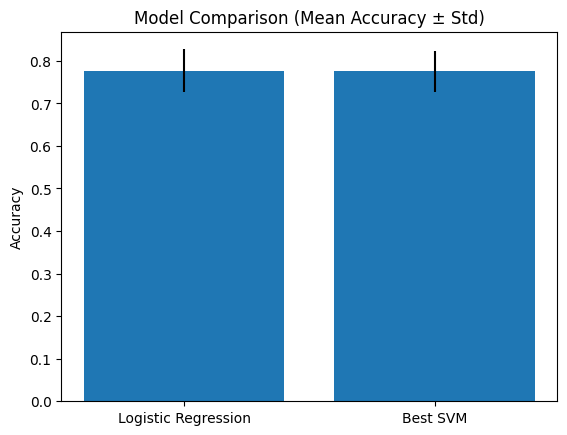

Logistic Mean: 0.7769962982548917 Std: 0.05015763567889165
SVM Mean: 0.775383395029085 Std: 0.0483392842292798


In [27]:
# Cross Validation + Stability

from sklearn.model_selection import cross_val_score

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_scores = cross_val_score(log_model, X_train_scaled, y_train, cv=10)

# Best SVM from previous grid
best_svm = grid_svm.best_estimator_
svm_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=10)

# Compute mean and std
models = ["Logistic Regression", "Best SVM"]
means = [log_scores.mean(), svm_scores.mean()]
stds = [log_scores.std(), svm_scores.std()]

# Plot
plt.figure()
plt.bar(models, means, yerr=stds)
plt.title("Model Comparison (Mean Accuracy ± Std)")
plt.ylabel("Accuracy")
plt.show()

print("Logistic Mean:", log_scores.mean(), "Std:", log_scores.std())
print("SVM Mean:", svm_scores.mean(), "Std:", svm_scores.std())

In [22]:
# Create new feature
X_train_new = X_train.copy()
X_test_new = X_test.copy()

X_train_new["Insulin_BMI"] = X_train_new["Insulin"] / (X_train_new["BMI"] + 1e-5)
X_test_new["Insulin_BMI"] = X_test_new["Insulin"] / (X_test_new["BMI"] + 1e-5)

# Scale again
scaler_new = StandardScaler()
X_train_new_scaled = scaler_new.fit_transform(X_train_new)
X_test_new_scaled = scaler_new.transform(X_test_new)

# Retrain best SVM
best_svm.fit(X_train_new_scaled, y_train)

# Evaluate
from sklearn.metrics import accuracy_score

y_pred_new = best_svm.predict(X_test_new_scaled)
print("Accuracy after feature engineering:", accuracy_score(y_test, y_pred_new))

Accuracy after feature engineering: 0.7857142857142857
